# Wakefield: an RF gun

The same `cav.wakefield` flow on a VHF-type RF gun. `beampipe='both'` adds the cathode pipe (the exit drift is already built in), so ABCI sees a pipe at each end.

> Needs the bundled `ABCI.exe` (Windows) / `abci` on PATH; ABCI needs a beam pipe at **both** ends.

In [1]:
import os, tempfile
import numpy as np
import matplotlib.pyplot as plt
from cavsim2d import RFGun
from cavsim2d.utils.style import apply_style
apply_style()

WF = {'MROT': 2, 'wakelength': 20, 'bunch_length': 25}

## The cavity

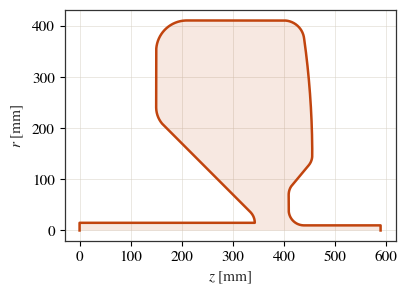

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
gun = {'geometry': {'y1': 1.5e-2, 'R2': 3e-2, 'T2': np.deg2rad(45), 'L3': 24e-2,
                    'R4': 5e-2, 'L5': 11e-2, 'R6': 6e-2, 'L7': 19e-2, 'R8': 4e-2,
                    'T9': np.deg2rad(8), 'R10': 3e-2, 'T10': np.deg2rad(40),
                    'L11': 5e-2, 'R12': 3e-2, 'L13': 3e-2, 'R14': 3e-2, 'x': 1e-2}}
rfgun = RFGun(gun, beampipe='both'); rfgun.name = 'rfgun'
rfgun.set_workspace(os.path.join(tempfile.mkdtemp(), 'rfgun_wf'))
rfgun.plot('geometry')

In [3]:
rfgun.wakefield.run(WF)
rfgun.wakefield.qois

{'|k_loss| [V/pC]': 0.3122,
 'k_FM [V/pC]': 0.06275,
 'k_loss_HOM [V/pC]': 0.24944999999999998,
 '|k_kick| [V/pC/m]': 26.46}

## Impedance and wake

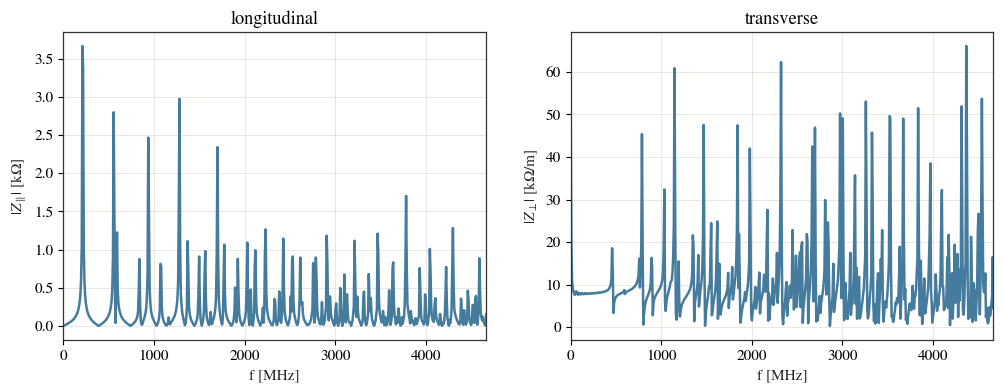

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
rfgun.wakefield.plot_impedance('longitudinal', ax=a1, show=False)
rfgun.wakefield.plot_impedance('transverse', ax=a2, show=False)
a1.set_title('longitudinal'); a2.set_title('transverse'); plt.show()

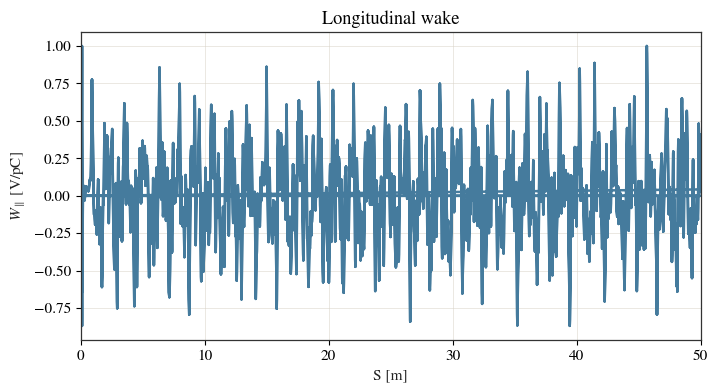

<Axes: title={'center': 'Longitudinal wake'}, xlabel='S [m]', ylabel='$W_\\parallel$ [V/pC]'>

In [5]:
rfgun.wakefield.plot_wake('longitudinal')

## Where to go next

- [Wakefield: a spline cavity](spline.ipynb) · [a reentrant cavity](reentrant.ipynb) · [varying a parameter](parameter_sweep.ipynb).
- [Multipacting: an RF gun](../multipacting/rfgun.ipynb) — the bare gun.